# LangGraph + Sequential Thinking MCP 튜토리얼

이 튜토리얼에서는 **Sequential Thinking MCP 서버**를 LangGraph와 통합하여 구조화된 단계별 추론을 수행하는 방법을 학습합니다.

Sequential Thinking MCP 서버는 복잡한 문제를 체계적으로 분석하고, 사고 과정을 단계별로 기록하며, 필요시 이전 단계를 수정하거나 대안적 사고 경로를 탐색할 수 있는 도구를 제공합니다.

> 참고 문서: [Sequential Thinking MCP Server](https://github.com/modelcontextprotocol/servers/tree/main/src/sequentialthinking)
> https://github.com/modelcontextprotocol/servers/tree/main/src/everything
## 학습 목표

- Sequential Thinking MCP 서버의 개념과 도구 파라미터를 이해합니다
- `create_agent`를 사용하여 Sequential Thinking 도구를 활용하는 에이전트를 생성합니다
- `ToolNode` 워크플로우에 Sequential Thinking을 통합합니다
- 복잡한 문제 분석과 계획 수립에 활용하는 방법을 실습합니다

## 목차

1. 환경 설정
2. Sequential Thinking MCP 소개
3. MCP 서버 연결
4. `create_agent`를 활용한 Sequential Thinking
5. `ToolNode` 워크플로우와 Sequential Thinking 통합

## 환경 설정

튜토리얼을 시작하기 전에 필요한 환경을 설정합니다. `dotenv`를 사용하여 API 키를 로드하고, `langchain_teddynote`의 로깅 기능을 활성화하여 LangSmith에서 실행 과정을 확인할 수 있도록 합니다.

In [1]:
from dotenv import load_dotenv
from langchain_teddynote import logging

# 환경 변수 로드
load_dotenv(override=True)
# 추적을 위한 프로젝트 이름 설정
logging.langsmith("LangGraph-V1-Tutorial")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-V1-Tutorial


---

## Part 1: Sequential Thinking MCP 소개

### Sequential Thinking이란?

Sequential Thinking MCP 서버는 **구조화된 단계별 사고 과정**을 지원하는 MCP 서버입니다. LLM이 복잡한 문제를 해결할 때 체계적으로 사고를 진행하고, 필요시 이전 단계를 수정하거나 대안적 경로를 탐색할 수 있도록 합니다.

### 주요 특징

- **단계별 분해**: 복잡한 문제를 관리 가능한 단계로 나눕니다
- **사고 수정(Revision)**: 이해가 깊어지면 이전 사고를 수정할 수 있습니다
- **분기 탐색(Branching)**: 대안적 추론 경로를 탐색할 수 있습니다
- **동적 조정**: 필요한 사고 단계 수를 동적으로 조정합니다

### `sequential_thinking` 도구 파라미터

| 파라미터 | 타입 | 필수 | 설명 |
|---------|------|------|------|
| `thought` | string | ✅ | 현재 추론 단계의 내용 |
| `nextThoughtNeeded` | boolean | ✅ | 다음 사고 단계가 필요한지 여부 |
| `thoughtNumber` | integer | ✅ | 현재 단계 번호 (1, 2, 3, ...) |
| `totalThoughts` | integer | ✅ | 예상되는 전체 단계 수 |
| `isRevision` | boolean | ❌ | 이전 사고를 수정하는 단계인지 여부 |
| `revisesThought` | integer | ❌ | 수정 대상 단계 번호 |
| `branchFromThought` | integer | ❌ | 분기 시작 단계 번호 |
| `branchId` | string | ❌ | 분기 경로 이름 |
| `needsMoreThoughts` | boolean | ❌ | 추가 단계 필요 여부 |

### 활용 사례

- 복잡한 문제 분석 및 분해
- 수정 가능성이 있는 계획 수립 및 설계
- 방향 전환이 필요할 수 있는 분석
- 초기 이해가 불완전한 상태에서의 탐색
- 컨텍스트 유지가 필요한 다단계 추론

In [2]:
import nest_asyncio
from typing import List, Dict, Any

from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver

# MCP 클라이언트: 여러 MCP 서버에 연결하여 도구를 가져옵니다
from langchain_mcp_adapters.client import MultiServerMCPClient

# 비동기 호출을 활성화합니다 (Jupyter 환경에서 필요)
nest_asyncio.apply()

In [3]:
import sys, os, subprocess

# Windows + Jupyter workaround: MCP stdio passes Jupyter's sys.stderr to subprocess.Popen,
# but Jupyter's stderr doesn't support fileno(). Patch the default errlog to os.devnull.
if sys.platform == "win32":
    import mcp.client.stdio as _mcp_stdio

    _devnull_file = open(os.devnull, "w")

    # @asynccontextmanager wraps the original function — patch __wrapped__.__defaults__
    if hasattr(_mcp_stdio.stdio_client, "__wrapped__"):
        _mcp_stdio.stdio_client.__wrapped__.__defaults__ = (_devnull_file,)

    # Also patch the helper that creates the subprocess
    _mcp_stdio._create_platform_compatible_process.__defaults__ = (
        None,
        _devnull_file,
        None,
    )


async def setup_mcp_client(server_configs: dict):
    """MCP 클라이언트를 설정하고 도구를 가져옵니다.

    Args:
        server_configs: 서버 구성 딕셔너리. 각 서버의 이름을 키로,
                       연결 정보(command, args, transport 또는 url)를 값으로 가집니다.

    Returns:
        tuple: (MCP 클라이언트, 로드된 도구 목록)
    """
    # MCP 클라이언트 생성
    client = MultiServerMCPClient(server_configs)

    # 서버에 연결하여 도구 목록을 가져옵니다
    tools = await client.get_tools()

    # 로드된 도구 목록을 출력합니다
    print(f"[MCP] {len(tools)}개의 도구가 로드되었습니다:")
    for tool in tools:
        print(f"  - {tool.name}")

    return client, tools

---

## Part 2: MCP 서버 연결

Sequential Thinking MCP 서버는 `npx`를 통해 실행할 수 있습니다. stdio 전송 방식을 사용하여 서버를 로컬 프로세스로 실행하고 표준 입출력으로 통신합니다.

> **참고**: `npx`를 사용하려면 Node.js가 설치되어 있어야 합니다.

In [4]:
# Sequential Thinking MCP 서버 구성 (stdio 전송 방식)
server_configs = {
    "sequential_thinking": {
        "command": "npx",
        "args": ["-y", "@modelcontextprotocol/server-sequential-thinking"],
        "transport": "stdio",
    },
}

# MCP 클라이언트 생성 및 도구 로드
client, tools = await setup_mcp_client(server_configs=server_configs)

[MCP] 1개의 도구가 로드되었습니다:
  - sequentialthinking


---

## Part 3: `create_agent`를 활용한 Sequential Thinking

에이전트를 생성하여 Sequential Thinking 도구를 활용합니다. 에이전트는 복잡한 질문을 받으면 자동으로 `sequential_thinking` 도구를 호출하여 단계별로 사고를 진행합니다.

In [5]:
# LLM 설정
# OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
llm = init_chat_model("claude-sonnet-4-5", temperature=0)

# 에이전트 생성: Sequential Thinking 도구를 사용하는 에이전트
agent = create_agent(
    llm,
    tools,
    checkpointer=InMemorySaver(),  # 대화 상태를 메모리에 저장
)

In [6]:
# 스트리밍 헬퍼 함수와 UUID 생성 함수를 import합니다
from langchain_teddynote.messages import astream_graph, random_uuid
from langchain_core.runnables import RunnableConfig

### 예제 1: 복잡한 문제 분석

마이크로서비스 아키텍처 전환에 대한 복잡한 질문을 단계별로 분석합니다.

In [7]:
# 대화 스레드 ID를 설정합니다
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 복잡한 문제 분석
response = await astream_graph(
    agent,
    inputs={"messages": [("human", "모놀리식 아키텍처에서 마이크로서비스 아키텍처로 전환할 때 고려해야 할 사항들을 단계별로 분석해 주세요.")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "thoughtNumber": 10,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 1,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 3,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 5,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 11,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 9,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 6,
  "totalThoughts": 12,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{

### 예제 2: 계획 수립

Python 웹 애플리케이션 성능 최적화를 위한 체계적인 계획을 수립합니다.

In [8]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 에이전트 실행: 계획 수립
response = await astream_graph(
    agent,
    inputs={"messages": [("human", "Python 웹 애플리케이션의 성능을 최적화하기 위한 단계별 계획을 세워주세요. 프로파일링부터 배포까지 포함해 주세요.")]},
    config=config,
)


🔄 Node: model 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{
  "thoughtNumber": 6,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 2,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 4,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 3,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 1,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 9,
  "totalThoughts": 10,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thoughtNumber": 7,
  "totalThoughts": 8,
  "nextThoughtNeeded": true,
  "branches": [],
  "thoughtHistoryLength": 1
}{
  "thou

---

## Part 4: `ToolNode` 워크플로우와 Sequential Thinking 통합

보다 세밀한 제어가 필요한 경우 `ToolNode`와 `StateGraph`를 사용하여 커스텀 워크플로우를 구성할 수 있습니다. Tavily 검색 도구와 함께 사용하면 단계별 사고와 실시간 정보 검색을 결합할 수 있습니다.

In [9]:
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage
from typing import Annotated, List, Dict, Any, TypedDict
from langchain_tavily import TavilySearch


class AgentState(TypedDict):
    """에이전트 상태 정의

    Attributes:
        messages: 대화 메시지 목록. add_messages 리듀서로 메시지가 누적됩니다.
        context: 추가 컨텍스트 정보를 저장하는 딕셔너리 (선택적)
    """

    messages: Annotated[List[BaseMessage], add_messages]
    context: Dict[str, Any]


async def create_mcp_workflow(server_configs: dict):
    """MCP 도구를 사용하는 커스텀 워크플로우를 생성합니다.

    이 함수는 MCP 도구와 Tavily 검색 도구를 결합하여
    에이전트-도구 루프를 구현하는 그래프를 생성합니다.

    Args:
        server_configs: MCP 서버 구성 딕셔너리

    Returns:
        CompiledStateGraph: 컴파일된 워크플로우 그래프
    """
    # MCP 클라이언트 생성 및 도구 로드
    client, tools = await setup_mcp_client(server_configs=server_configs)

    # Tavily 웹 검색 도구 추가
    tavily_tool = TavilySearch(max_results=2)
    tools.append(tavily_tool)

    # LLM 설정 및 도구 바인딩
    # OpenAI 키 사용 시 gpt-5.2, gpt-4.1-mini 등으로 변경 가능
    llm = init_chat_model("claude-sonnet-4-5", temperature=0)
    llm_with_tools = llm.bind_tools(tools)

    # 워크플로우 그래프 생성
    workflow = StateGraph(AgentState)

    async def agent_node(state: AgentState):
        """에이전트 노드: LLM을 호출하여 응답을 생성합니다"""
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}

    # ToolNode 생성: 도구 호출을 처리합니다
    tool_node = ToolNode(tools)

    # 그래프에 노드 추가
    workflow.add_node("agent", agent_node)
    workflow.add_node("tools", tool_node)

    # 엣지 정의: 시작 -> 에이전트
    workflow.add_edge(START, "agent")

    # 조건부 엣지: 에이전트 -> (도구 or 종료)
    # tools_condition은 도구 호출이 필요하면 "tools"로, 아니면 END로 라우팅합니다
    workflow.add_conditional_edges("agent", tools_condition)

    # 도구 -> 에이전트 (도구 실행 후 다시 에이전트로)
    workflow.add_edge("tools", "agent")

    # 그래프 컴파일
    app = workflow.compile(checkpointer=InMemorySaver())

    return app

In [10]:
# Sequential Thinking + Tavily 워크플로우 생성
server_configs = {
    "sequential_thinking": {
        "command": "npx",
        "args": ["-y", "@modelcontextprotocol/server-sequential-thinking"],
        "transport": "stdio",
    },
}

mcp_app = await create_mcp_workflow(server_configs)

[MCP] 1개의 도구가 로드되었습니다:
  - sequentialthinking


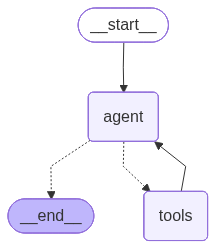

In [11]:
from IPython.display import Image

# 컴파일된 워크플로우 그래프를 시각화합니다
Image(mcp_app.get_graph().draw_mermaid_png())

### 예제 3: 단계별 사고 + 웹 검색 결합

Sequential Thinking으로 체계적으로 사고하면서, Tavily 검색으로 실시간 정보를 수집하는 복합 작업을 수행합니다.

In [12]:
# 새로운 대화 스레드 생성
config = RunnableConfig(configurable={"thread_id": random_uuid()})

# 워크플로우 실행: 단계별 사고 + 웹 검색
_ = await astream_graph(
    mcp_app,
    inputs={
        "messages": [
            (
                "human",
                "2025년 AI 에이전트 프레임워크의 최신 동향을 조사하고, LangGraph의 경쟁력을 단계별로 분석해 주세요.",
            )
        ]
    },
    config=config,
)


🔄 Node: agent 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 

🔄 Node: tools 🔄
- - - - - - - - - - - - - - - - - - - - - - - - - 
{"query": "2025 AI agent framework trends latest developments", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.shakudo.io/blog/top-9-ai-agent-frameworks", "title": "Top 9 AI Agent Frameworks as of March 2026", "content": "This is particularly beneficial for use cases like building conversational assistants, automated document analysis and summarization, personalized recommendation systems, and research assistants across various domains. We’d recommend this framework for both mature corporations and beginner startups. It's particularly well-suited for mature companies, especially those with large-scale natural language processing (NLP) use cases, as well as startups developing AI-powered products. [...] ## 8. Hugging Face Transformers Agents\n\nHugging Face recently introduced the Transformers Agents framewor

---

## 마무리

이 튜토리얼에서는 Sequential Thinking MCP 서버를 LangGraph와 통합하는 방법을 학습했습니다.

### 핵심 정리

- **Sequential Thinking MCP 서버**는 `npx -y @modelcontextprotocol/server-sequential-thinking`으로 간편하게 실행할 수 있습니다
- `sequential_thinking` 도구는 `thought`, `thoughtNumber`, `totalThoughts`, `nextThoughtNeeded` 파라미터로 단계별 사고를 구조화합니다
- `isRevision`, `branchFromThought` 등 선택적 파라미터로 사고의 수정과 분기를 지원합니다
- `create_agent`로 간단한 에이전트를, `ToolNode` + `StateGraph`로 커스텀 워크플로우를 구성할 수 있습니다
- Tavily 등 다른 도구와 결합하면 체계적 사고와 정보 수집을 동시에 수행할 수 있습니다

### 활용 팁

- 복잡한 설계 결정이 필요한 경우 Sequential Thinking으로 체계적으로 접근하세요
- 초기 분석이 불완전할 수 있는 탐색적 문제에 특히 유용합니다
- 다른 MCP 도구(검색, RAG 등)와 함께 사용하면 더 강력한 분석이 가능합니다